## Multi-Model Application practice


In [8]:
# load libraries
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()

True

In [9]:
# call the API keys from environment variables
Groq_api_key = os.getenv("GROQ_API_KEY")
if Groq_api_key is None:
    raise ValueError("GROQ_API_KEY not found in environment variables")

Gemini_api_key = os.getenv("GEMINI_API_KEY")
if Gemini_api_key is None:
    raise ValueError("GEMINI_API_KEY not found in environment variables")

hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN") # name convention for Hugging Face API key is "HUGGINGFACEHUB_API_TOKEN"
if hf_token is None:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN not found in environment variables")

In [10]:
# step 1 - text to text 
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    max_tokens=1024,
    temperature=0,
    # reasoning_format={"reasoning_format": "parsed"}
    )

e:\Ai_engeering letecture_n_notes\assignment_multimodel_application\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from langchain_core.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(content="You are a senior ML engineer. Be concise and technical."),
    HumanMessage(content="Explain what a transformer is in 3 lines.")
]

response = llm.invoke(messages)
print(response.content)

**Transformer Architecture**: A transformer is a type of neural network introduced in 2017, primarily used for natural language processing tasks. It relies on self-attention mechanisms to weigh the importance of different input elements relative to each other, allowing for parallelization and efficient processing of sequential data. The architecture consists of an encoder and a decoder, with the encoder generating continuous representations of input sequences.


In [12]:
# step 2 - image to text
#from langchain_groq import Groqvision
from langchain_google_genai import ChatGoogleGenerativeAI
import base64

# read the image and convert to base64

with open("test.jpg", "rb") as file:
    image_data = base64.b64encode(file.read()).decode("utf-8")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    max_tokens=1024,
    temperature=1.0,
)

messages = [
    HumanMessage(
        content=[
            {"type": "image_url", "image_url":{"url": f"data:image/jpeg;base64,{image_data}"}},
            {"type": "text", "text": "describe the provided image in brief"}
        ]
    )]
response = llm.invoke(messages)
print(response)

content=[{'type': 'text', 'text': "This is a stylized, painterly digital illustration of a narrow Japanese alleyway (often called a *yokocho*). \n\nThe image features:\n*   **Artistic Style:** A vibrant, cartoon-like aesthetic with bold outlines and a color palette dominated by shades of green, teal, and yellow.\n*   **Subject:** A dense street lined with storefronts, restaurants, and numerous hanging signs adorned with Japanese characters.\n*   **Key Details:** On the right, there is a prominent sign featuring a cartoon illustration of a smiling, sitting monk or deity. Lanterns, menu boards, and a parked bicycle line the pathway, drawing the viewer's eye down the cluttered lane.", 'extras': {'signature': 'EqMeCqAeAQw51seVunKe/GXvoCuTzO+6rLy3ZoFLGboqWXxdt8vxN0DkTplMVBrz9kKtcjAptuLLjRgKDBVz4gF/cIDn2dgMjYFQv4KqgMrc1GxibnY8FByChjxGKWi61JZw1HzirQ7dYkn8KEPBtexENHuMF7mLnGe0dg+VZ3eu+iq+EkdLH4FAcKF8c6GnyWV0LDZfnsF6AFbxsqnFkxS8IxTZ3iGQXA/usnt0c9ti4pH/pyUDuK8US6mWpL6yaL632/EWTDeW1LacFZtNg9pv9rS+

In [13]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="nscale",
    api_key=hf_token,
)
prompt = "Naruto running in the rain, cinematic, highly detailed, artstation, concept art, digital painting"
# output is a PIL.Image object
image = client.text_to_image(
    prompt=prompt,
    model="stabilityai/stable-diffusion-xl-base-1.0",
)
image.save("output.png")

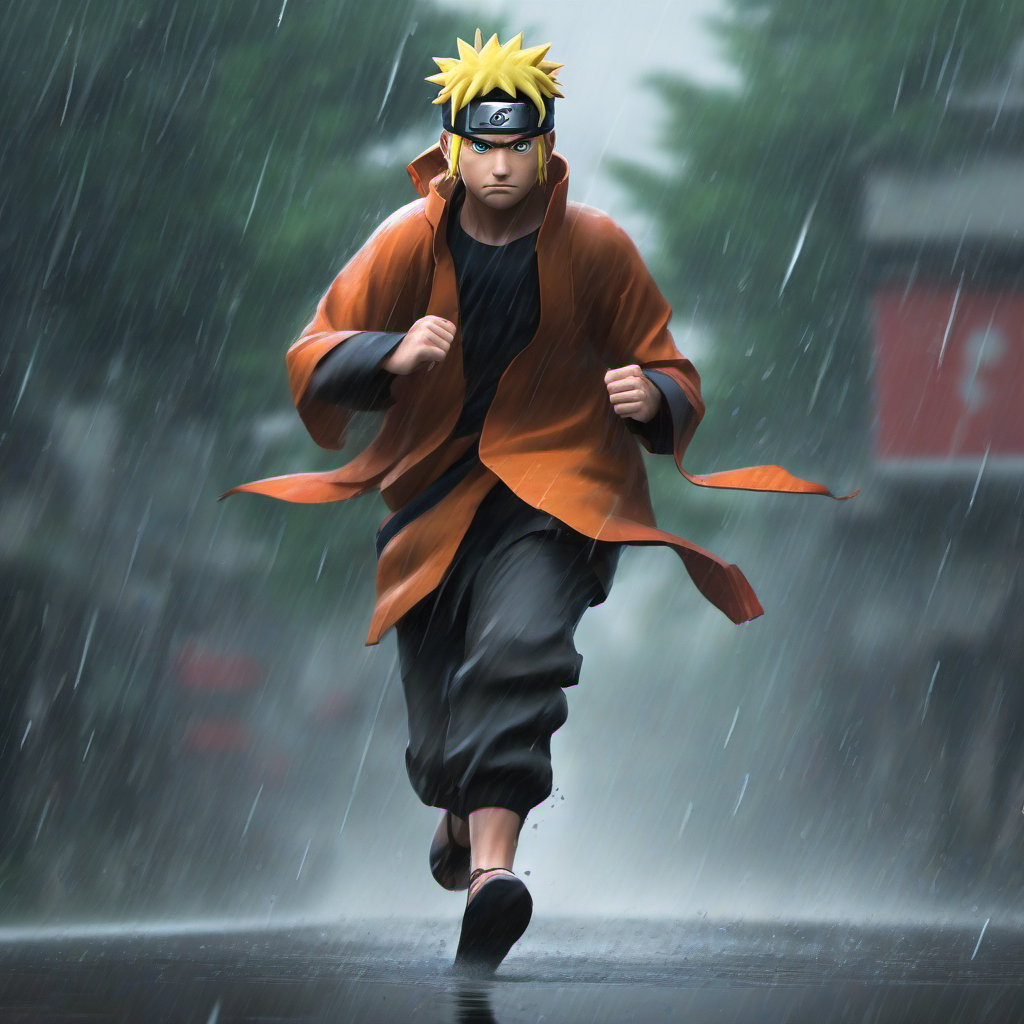

In [14]:
image

In [15]:
# text to voice and image to voice
from google import genai
from google.genai import types
import wave

In [21]:
client = genai.Client(api_key=Gemini_api_key)

# text to voice
response = client.models.generate_content(
   model="gemini-3.1-flash-tts-preview",
   contents="If I can't even protect my captain's dream, then whatever ambition I have is just a joke!.",
   config=types.GenerateContentConfig(
      response_modalities=["AUDIO"],
      speech_config=types.SpeechConfig(
         voice_config=types.VoiceConfig(
            prebuilt_voice_config=types.PrebuiltVoiceConfig(
               voice_name='Kore',
            )
         )
      ),
   )
)

In [22]:
audio_data = response.candidates[0].content.parts[0].inline_data.data

with wave.open("output.wav", "wb") as wav_file:
    wav_file.setnchannels(1)  # mono
    wav_file.setsampwidth(2)  # 16-bit audio
    wav_file.setframerate(24000)  # 24 kHz sample rate
    wav_file.writeframes(audio_data)